<a href="https://colab.research.google.com/github/shahdelsayed-ss/titanic-data-set-with-logistic/blob/main/titanic_logistic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
priyankamohanta_taitanictrain_path = kagglehub.dataset_download('priyankamohanta/taitanictrain')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/priyankamohanta/taitanictrain/datasets_11657_16098_train.csv


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv("/kaggle/input/datasets/priyankamohanta/taitanictrain/datasets_11657_16098_train.csv")

In [ ]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
df.shape


(891, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.drop("Name",axis=1 ,inplace=True)

In [ ]:
df.drop("PassengerId",axis=1 ,inplace=True)

In [ ]:
df.drop("Ticket",axis=1 ,inplace=True)

In [ ]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin',
       'Embarked'],
      dtype='object')

In [ ]:
df.duplicated().sum()

np.int64(107)

In [ ]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [ ]:
df.drop("Cabin",axis=1 ,inplace=True)

(array([ 54.,  46., 177., 169., 118.,  70.,  45.,  24.,   9.,   2.]),
 array([ 0.42 ,  8.378, 16.336, 24.294, 32.252, 40.21 , 48.168, 56.126,
        64.084, 72.042, 80.   ]),
 <BarContainer object of 10 artists>)

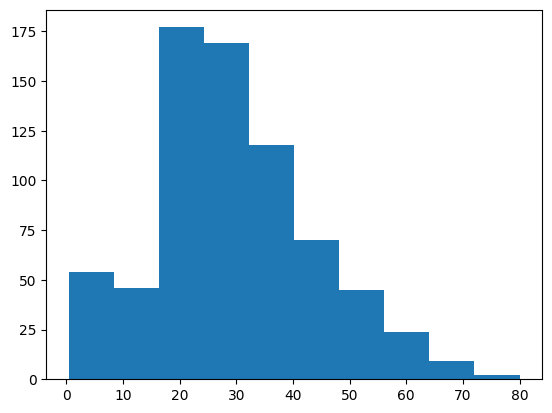

In [ ]:
import matplotlib.pyplot as plt
plt.hist(df["Age"])

In [ ]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [ ]:
df["Age"] = df["Age"].round().astype(int)

In [ ]:
df.head(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22,1,0,7.2500,S
1,1,1,female,38,1,0,71.2833,C
2,1,3,female,26,0,0,7.9250,S
3,1,1,female,35,1,0,53.1000,S
4,0,3,male,35,0,0,8.0500,S


In [ ]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode())

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    int64  
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(1), int64(5), object(2)
memory usage: 55.8+ KB


In [ ]:
for col in df.select_dtypes(include=["int64", "float64"]).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Survived: 0 outliers
Pclass: 0 outliers
Age: 66 outliers
SibSp: 46 outliers
Parch: 213 outliers
Fare: 116 outliers


{'whiskers': [<matplotlib.lines.Line2D at 0x784006a9af60>,
 'caps': [<matplotlib.lines.Line2D at 0x78400694daf0>,
 'boxes': [<matplotlib.lines.Line2D at 0x78400694d250>],
 'medians': [<matplotlib.lines.Line2D at 0x78400694e240>],
 'fliers': [<matplotlib.lines.Line2D at 0x78400694e510>],
 'means': []}

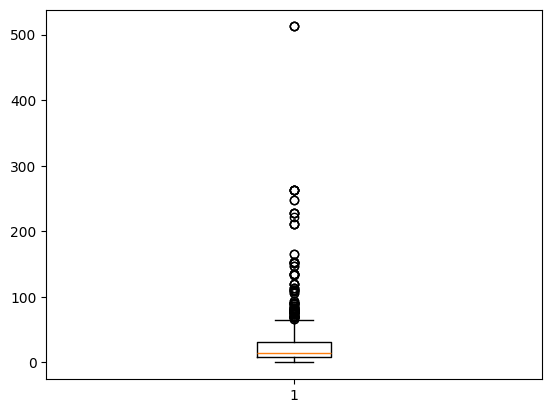

In [ ]:
plt.boxplot(df["Fare"])

In [ ]:
df["Fare"]=df["Fare"].clip(lower,upper)

In [ ]:
len(df[(df["Fare"] < lower) | (df["Fare"] > upper)])

0

{'whiskers': [<matplotlib.lines.Line2D at 0x7840068b3860>,
 'caps': [<matplotlib.lines.Line2D at 0x78400698aed0>,
 'boxes': [<matplotlib.lines.Line2D at 0x784006962ea0>],
 'medians': [<matplotlib.lines.Line2D at 0x78400698b530>],
 'fliers': [<matplotlib.lines.Line2D at 0x78400698b860>],
 'means': []}

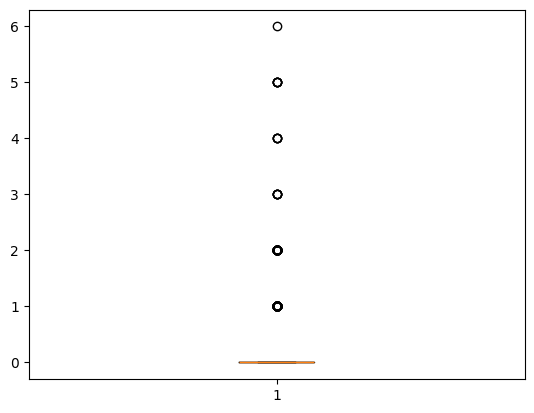

In [ ]:
plt.boxplot(df["Parch"])

{'whiskers': [<matplotlib.lines.Line2D at 0x78400473c950>,
 'caps': [<matplotlib.lines.Line2D at 0x78400473f4a0>,
 'boxes': [<matplotlib.lines.Line2D at 0x78400473ee70>],
 'medians': [<matplotlib.lines.Line2D at 0x78400698c260>],
 'fliers': [<matplotlib.lines.Line2D at 0x78400698c500>],
 'means': []}

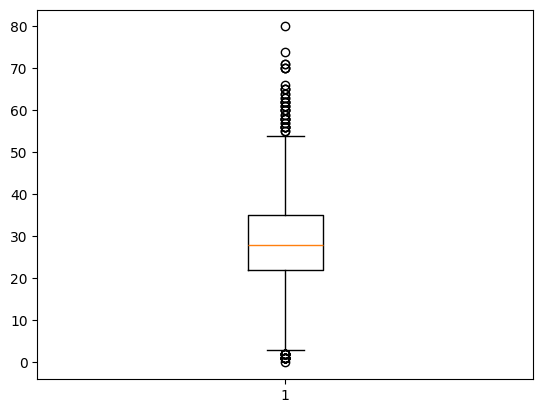

In [ ]:
plt.boxplot(df["Age"])

{'whiskers': [<matplotlib.lines.Line2D at 0x784004630860>,
 'caps': [<matplotlib.lines.Line2D at 0x784004630e30>,
 'boxes': [<matplotlib.lines.Line2D at 0x7840046305c0>],
 'medians': [<matplotlib.lines.Line2D at 0x784004631400>],
 'fliers': [<matplotlib.lines.Line2D at 0x7840046316a0>],
 'means': []}

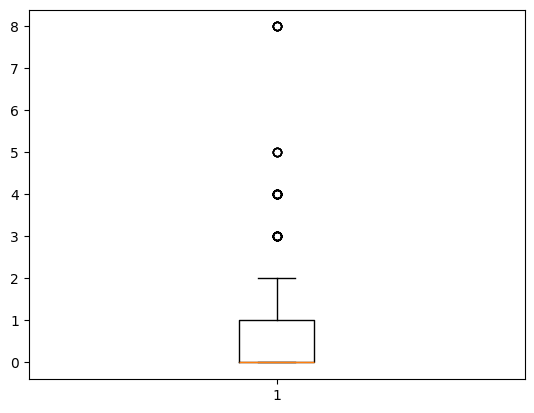

In [ ]:
plt.boxplot(df["SibSp"])

In [ ]:
df["Family_Size"] = df["SibSp"] + df["Parch"] + 1

In [ ]:
df.drop(["SibSp", "Parch"], axis=1, inplace=True)

In [ ]:
# df["Age_Group"] = pd.cut(
#     df["Age"],
#     bins=[0, 12, 18, 35, 60, 100],
#     labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
# )

In [ ]:
# from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()
# df["Age_Group"] = le.fit_transform(df["Age_Group"])

In [ ]:
# df.drop("Age", axis=1, inplace=True)

In [ ]:
df.describe()

,Survived,Pclass,Age,Fare,Family_Size
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.356902,24.046813,1.904602
std,0.486592,0.836071,13.017814,20.481625,1.613459
min,0.000000,1.000000,0.000000,0.000000,1.000000
25%,0.000000,2.000000,22.000000,7.910400,1.000000
50%,0.000000,3.000000,28.000000,14.454200,1.000000
75%,1.000000,3.000000,35.000000,31.000000,2.000000
max,1.000000,3.000000,80.000000,65.634400,11.000000


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Sex"] = le.fit_transform(df["Sex"])
df["Embarked"] = le.fit_transform(df["Embarked"])

In [ ]:
df

,Survived,Pclass,Sex,Age,Fare,Embarked,Family_Size
0,0,3,1,22,7.2500,2,2
1,1,1,0,38,65.6344,0,2
2,1,3,0,26,7.9250,2,1
3,1,1,0,35,53.1000,2,2
4,0,3,1,35,8.0500,2,1
...,...,...,...,...,...,...,...
886,0,2,1,27,13.0000,2,1
887,1,1,0,19,30.0000,2,1
888,0,3,0,28,23.4500,2,4
889,1,1,1,26,30.0000,0,1


In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

In [ ]:
X = df.drop("Survived", axis=1)
y = df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy:  0.7988826815642458
Precision:  0.7794117647058824
Recall:  0.7162162162162162
F1 Score:  0.7464788732394366

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.86      0.83       105
           1       0.78      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

